# NLSY97 clean data — exploration

One row per person per interview round (age 18+, interviewed, marital status known).
Built by `src/clean_nlsy97.py`. `partnered` = married (spouse present or absent)
or cohabiting at the interview. The cohort was born 1980-84, so rounds 1997-2011
(annual) and 2013-2023 (biennial) cover ages ~18-43.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("data/clean/nlsy97.parquet")
print(f"{len(df):,} rows, {df['person_id'].nunique():,} people")
df.head(3)

131,644 rows, 8,851 people


,person_id,source,year,round,weight,age,sex,race_ethnicity,education,employed,...,religion,attendance_worship,importance_faith,big5_extraversion,big5_agreeableness,big5_conscientiousness,big5_emotional_stability,big5_openness,weight_kg,nonresident_children
0,nlsy97-670,nlsy97,1998,1,1086.73,18,male,hispanic,less_than_hs,0.0,...,protestant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,104.326245,-4.0
1,nlsy97-822,nlsy97,1998,1,821.86,18,female,black,less_than_hs,0.0,...,protestant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,81.646627,0.0
2,nlsy97-1289,nlsy97,1998,1,2987.59,18,male,other,less_than_hs,0.0,...,other,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57.606231,-4.0


## Partnered rate by age and sex

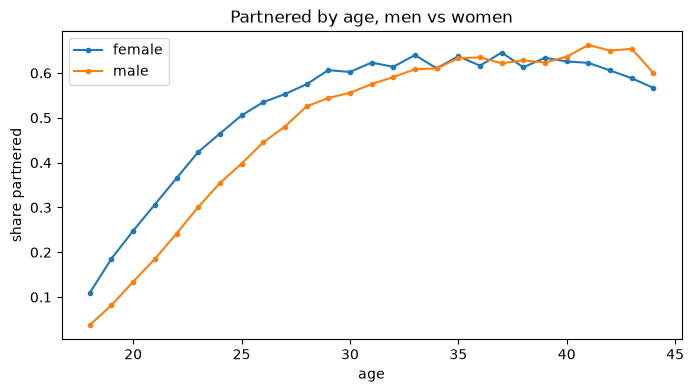

sex,female,male
age,,
37,0.646,0.622
38,0.613,0.628
39,0.634,0.623
40,0.626,0.636
41,0.623,0.663
42,0.606,0.650
43,0.588,0.654
44,0.567,0.600


In [2]:
pivot = df.groupby(["age", "sex"])["partnered"].agg(["mean", "count"]).unstack("sex")
ax = pivot["mean"].plot(figsize=(8, 4), marker="o", ms=3)
ax.set_ylabel("share partnered"); ax.set_title("Partnered by age, men vs women")
ax.legend(title=None); plt.show()
pivot["mean"].round(3).tail(8)

In [3]:
print(df.groupby("sex")["partnered"].agg(["count", "mean"]).round(3))
# the average hides a crossover: women partner earlier, men catch up later
young = df[df["age"] < 30].groupby("sex")["partnered"].mean().round(3)
old = df[df["age"] >= 35].groupby("sex")["partnered"].mean().round(3)
pd.DataFrame({"under 30": young, "35 plus": old})

        count   mean
sex                 
female  65921  0.471
male    65723  0.400


,under 30,35 plus
sex,,
female,0.395,0.626
male,0.297,0.634


## Missing values per column

The Big Five and `importance_faith` are missing on ~half the rows by design:
TIPI was measured in 2008 and importance of faith was first asked in 2008, and
earlier rounds must not use information from the future.

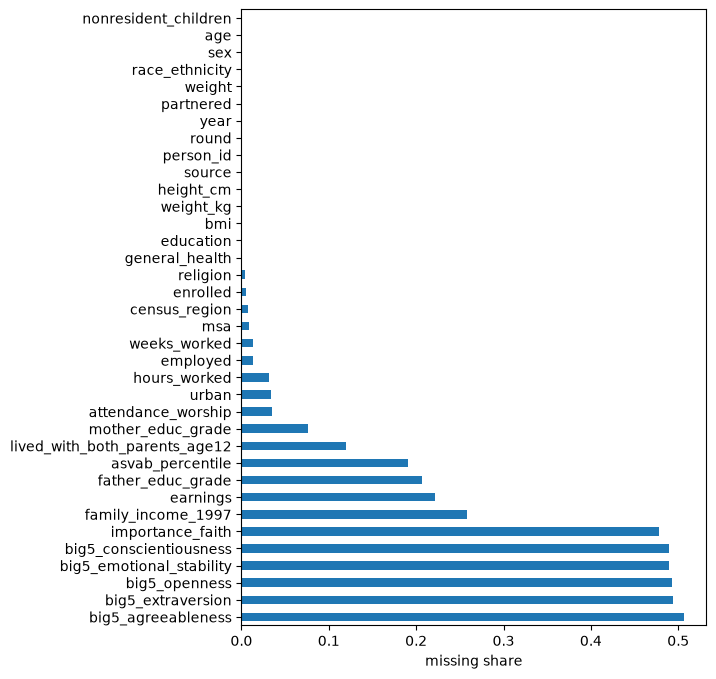

big5_agreeableness               0.507
big5_extraversion                0.494
big5_openness                    0.493
big5_emotional_stability         0.489
big5_conscientiousness           0.489
importance_faith                 0.478
family_income_1997               0.258
earnings                         0.221
father_educ_grade                0.207
asvab_percentile                 0.191
lived_with_both_parents_age12    0.120
mother_educ_grade                0.076
attendance_worship               0.035
urban                            0.034
hours_worked                     0.031
employed                         0.013
weeks_worked                     0.013
msa                              0.009
census_region                    0.008
enrolled                         0.005
religion                         0.004
general_health                   0.001
education                        0.001
bmi                              0.000
weight_kg                        0.000
height_cm                

In [4]:
missing = df.isna().mean().sort_values(ascending=False)
ax = missing.plot.barh(figsize=(6, 8))
ax.set_xlabel("missing share"); plt.show()
missing[missing > 0].round(3)

1. **Interview years spill over the nominal round year.** Fieldwork for a round
often runs into the next calendar year, so `year` (the actual interview year)
has rows in 2012, 2014, ..., 2024 even though no round happened then — and a
person can have two rows in the same calendar year. `person_id` x `round`
(survey round 1-21) is the unique key, not `person_id` x `year`.

In [5]:
print("rows in even years 2012+ (fieldwork spill):", df[(df["year"] >= 2012) & (df["year"] % 2 == 0)].shape[0])
print("person-year duplicates (two rounds interviewed in one calendar year):", df.duplicated(["person_id", "year"]).sum())
print("person x round duplicates (must be 0):", df.duplicated(["person_id", "round"]).sum())

rows in even years 2012+ (fieldwork spill): 15768
person-year duplicates (two rounds interviewed in one calendar year): 13871
person x round duplicates (must be 0): 0


2. **Bracket midpoints show up as spikes in earnings** — when the exact amount was refused, we imputed the show-card bracket midpoint.

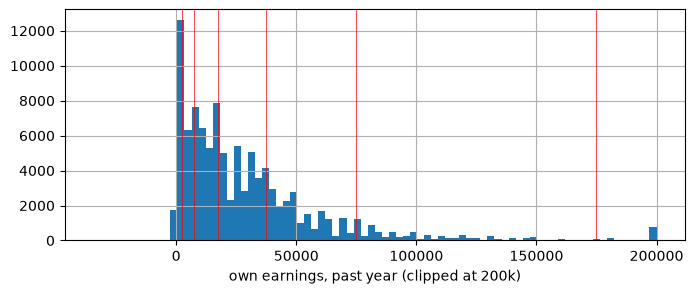

share of rows with earnings exactly at a bracket midpoint: 0.119


In [6]:
earn = df["earnings"].dropna()
ax = earn.clip(upper=200000).hist(bins=80, figsize=(8, 3))
for m in [2500, 7500, 17500, 37500, 75000, 175000]:
    plt.axvline(m, color="red", lw=0.5)
ax.set_xlabel("own earnings, past year (clipped at 200k)"); plt.show()
print("share of rows with earnings exactly at a bracket midpoint:",
      round(df["earnings"].isin([2500, 7500, 17500, 37500, 75000, 175000, 300000]).mean(), 3))

3. **Heights wobble**: nearly half of people's first and last recorded adult heights differ by more than 2 cm (mean 1.9 cm, max 51 cm). Part of that is real growth — early rows can carry a height reported at 16-17 — part is self-report noise. Worth remembering when height becomes a feature. Averages by sex look right:

In [7]:
first = df.sort_values("year").groupby("person_id")["height_cm"].first()
last = df.groupby("person_id")["height_cm"].last()
delta = (last - first).dropna()
print("adult height change between first and last round, cm:")
print(delta.abs().describe().round(1))
print("share who 'changed' by more than 2 cm:", (delta.abs() > 2).mean().round(3))
df.groupby("sex")["height_cm"].mean().round(1)

adult height change between first and last round, cm:
count    8851.0
mean        1.9
std         3.3
min         0.0
25%         0.0
50%         0.0
75%         2.5
max        50.8
Name: height_cm, dtype: float64
share who 'changed' by more than 2 cm: 0.486


sex
female    163.9
male      178.8
Name: height_cm, dtype: float64

4. **The 'no religion' share grows fast as the cohort ages** — but the panel mixes age and period, so this chart is age, year and generation all at once.

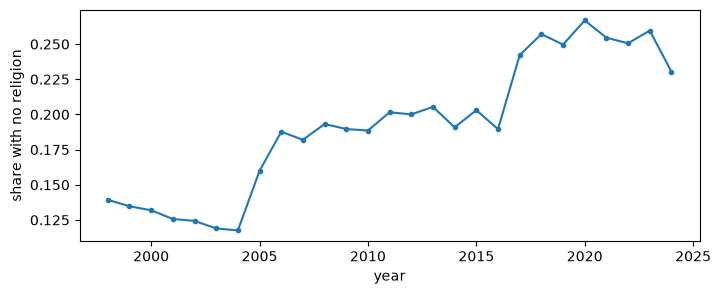

In [8]:
rel = df.dropna(subset=["religion"]).groupby("year")["religion"].apply(lambda s: (s == "none").mean())
ax = rel.plot(figsize=(8, 3), marker="o", ms=3)
ax.set_ylabel("share with no religion"); plt.show()

5. **`employed` means 'worked any weeks in the calendar year before the interview'** — broader than 'employed right now'. Distribution by sex and age:

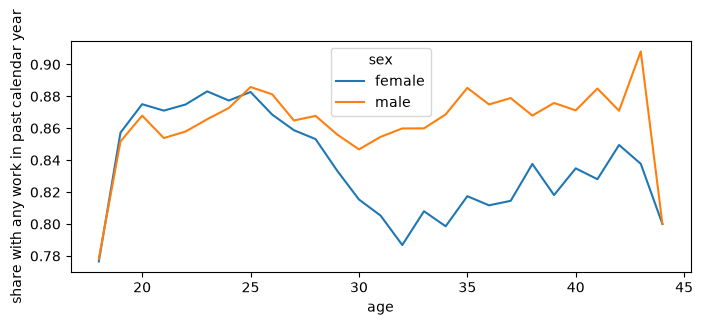

In [9]:
emp = df.groupby(["age", "sex"])["employed"].mean().unstack()
ax = emp.plot(figsize=(8, 3))
ax.set_ylabel("share with any work in past calendar year"); plt.show()